<a href="https://colab.research.google.com/github/sandinaniaaryan-afk/ML/blob/main/Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
excel=pd.ExcelFile("Lab Session Data (1).xlsx")
print(excel.sheet_names)
df=pd.read_excel(excel,sheet_name=0)
print(df.columns)
X = df[['Candies (#)',
        'Mangoes (Kg)',
        'Milk Packets (#)']]

y = df['Payment (Rs)']
X=X.values
y=y.values
print(X)
print(y)
print(X.shape)
print(y.shape)
df.info()
df.describe()
print(np.linalg.matrix_rank(X))
x=np.linalg.pinv(X)
C=x @ y
print("Cost of each product:",C)
df["Class"] = np.where(df["Payment (Rs)"].values > 200, "RICH", "POOR")

print(df)
df.to_excel("Lab Session Data with labels.xlsx", index=False)

['Purchase data', 'IRCTC Stock Price', 'thyroid0387_UCI', 'marketing_campaign']
Index(['Customer', 'Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)',
       'Payment (Rs)', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Candy', 'Mango', 'Milk'],
      dtype='object')
[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]
[386 289 393 110 280 167 271 274 148 198]
(10, 3)
(10,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer          10 non-null     object 
 1   Candies (#)       10 non-null     int64  
 2   Mangoes (Kg)      10 non-null     int64  
 3   Milk Packets (#)  10 non-null    

Package Mean: 1560.6634538152612
Own Mean: 1560.6634538152598
Package Variance: 58496.49239931613
Own Variance: 58496.49239931618
Average Time Mean: 4.307020000169359e-05
Average Time Variance: 0.00019052779999242375
Wednesday Sample Mean: 1550.7060000000001
Population Mean: 1560.6634538152612
April Sample Mean: 1698.9526315789474
Population Mean: 1560.6634538152612
Probability of Loss: 0.4979919678714859
Probability of Profit on Wednesday: 0.08433734939759036
Conditional Probability of Profit Given Wednesday: 0.42


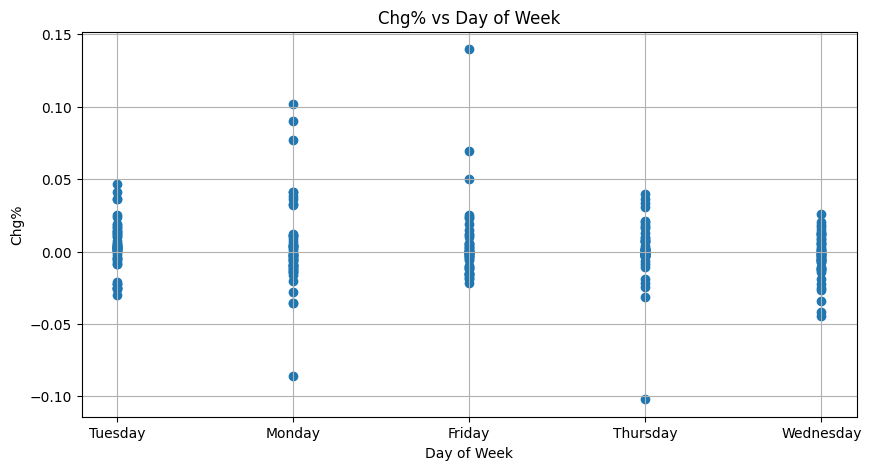

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="IRCTC Stock Price")

df.columns = df.columns.str.strip()

date_col = df.columns[0]
price_col = df.columns[3]
chg_col = df.columns[8]

df[date_col] = pd.to_datetime(df[date_col])

price = df[price_col].dropna().to_numpy()

package_mean = np.mean(price)
package_variance = np.var(price)

def my_mean(x):
    s = 0
    c = 0
    for i in x:
        s += i
        c += 1
    return s / c

def my_variance(x):
    m = my_mean(x)
    s = 0
    c = 0
    for i in x:
        s += (i - m) ** 2
        c += 1
    return s / c

my_mean_value = my_mean(price)
my_variance_value = my_variance(price)

t1 = []
for _ in range(10):
    st = time.perf_counter()
    my_mean(price)
    en = time.perf_counter()
    t1.append(en - st)

t2 = []
for _ in range(10):
    st = time.perf_counter()
    my_variance(price)
    en = time.perf_counter()
    t2.append(en - st)

print("Package Mean:", package_mean)
print("Own Mean:", my_mean_value)
print("Package Variance:", package_variance)
print("Own Variance:", my_variance_value)
print("Average Time Mean:", np.mean(t1))
print("Average Time Variance:", np.mean(t2))

wed = df[df[date_col].dt.day_name() == "Wednesday"]
wed_mean = wed[price_col].mean()

print("Wednesday Sample Mean:", wed_mean)
print("Population Mean:", package_mean)

apr = df[df[date_col].dt.month == 4]
apr_mean = apr[price_col].mean()

print("April Sample Mean:", apr_mean)
print("Population Mean:", package_mean)

loss_prob = len(df[df[chg_col].apply(lambda x: x < 0)]) / len(df)

print("Probability of Loss:", loss_prob)

profit_wed = len(wed[wed[chg_col] > 0]) / len(df)

print("Probability of Profit on Wednesday:", profit_wed)

conditional_profit_wed = len(wed[wed[chg_col] > 0]) / len(wed)

print("Conditional Probability of Profit Given Wednesday:", conditional_profit_wed)

plt.figure(figsize=(10,5))
plt.scatter(df[date_col].dt.day_name(), df[chg_col])
plt.xlabel("Day of Week")
plt.ylabel("Chg%")
plt.title("Chg% vs Day of Week")
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")

df.columns = df.columns.str.strip()

print("Data Types")
print(df.dtypes)

print("\nAttribute Types")
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(col, ":", "Numeric")
    else:
        if df[col].nunique() <= 10:
            print(col, ":", "Categorical (Nominal) -> One-Hot Encoding")
        else:
            print(col, ":", "Categorical (Ordinal/High Cardinality) -> Label Encoding")

print("\nNumeric Variable Range")
numeric = df.select_dtypes(include=np.number)
for col in numeric.columns:
    print(col)
    print("Minimum:", numeric[col].min())
    print("Maximum:", numeric[col].max())
    print()

print("Missing Values")
print(df.isnull().sum())

print("\nOutliers")
for col in numeric.columns:
    q1 = numeric[col].quantile(0.25)
    q3 = numeric[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = numeric[(numeric[col] < lower) | (numeric[col] > upper)]
    print(col, ":", len(outliers))

print("\nMean")
print(numeric.mean())

print("\nVariance")
print(numeric.var())

print("\nStandard Deviation")
print(numeric.std())

Data Types
Record ID                     int64
age                           int64
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measured     